PARTE NUMPY

In [ ]:
#ex1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
a = np.arange(0,100).tolist()
for i in a:
    a[i] = random.randint(1,100)
a
media = np.mean(a)
dp = np.std(a)
max = np.max(a)
media, dp, max
#2
norm = np.random.normal(0,1,25)
norm_ = norm.reshape(5,5)
norm_


ModuleNotFoundError: No module named 'seaborn'

In [2]:
print("Soma coluna")
print(np.sum(norm_,axis=0))
print("Soma linha")
print(np.sum(norm_,axis=1))


Soma coluna
[-0.1681083  -1.08179733  0.95124542  2.15322505 -0.68089393]
Soma linha
[ 2.12354609  0.36430833 -4.42007074  1.2657237   1.84016352]


In [3]:
#3
def produto(a,b):
    c = np.dot(a,b)
    d = np.linalg.norm(a-b)
    return("Produto escalar: ", c, ".", "Distancia euclidiana", d, ".")

In [4]:
#4
uniform = np.random.randint(-5,5,16)
uniform_ = uniform.reshape(4,4)
uniform_
if np.linalg.det(uniform_)!=0:
    print("Confirmação:")
    print(np.dot(np.linalg.inv(uniform_),uniform_))
else:
    print("Não inversível")

Confirmação:
[[ 1.00000000e+00  0.00000000e+00  2.22044605e-16  0.00000000e+00]
 [ 2.22044605e-16  1.00000000e+00 -2.77555756e-17  1.11022302e-16]
 [ 1.33226763e-15  0.00000000e+00  1.00000000e+00  4.44089210e-16]
 [ 0.00000000e+00  8.88178420e-16 -2.22044605e-16  1.00000000e+00]]


In [5]:
#5
M_a = np.random.randint(-5,5,25)
M_a = M_a.reshape(5,5)
B_a = .5*(np.dot(M_a,M_a.T))
B_a
e_vals, e_vecs = np.linalg.eig(B_a)
e_vals
e_vecs
B = []
h = 0
for i in e_vecs.T:
    B = np.dot(B_a,i)-e_vals[h]*i
    h = h + 1
print("Verificando valores proximos de zero: ", B)


Verificando valores proximos de zero:  [-5.27355937e-16 -5.32907052e-15  8.88178420e-16 -1.77635684e-15
 -1.77635684e-15]


In [6]:
#6
A_a = np.random.randint(-5,5,9)
y_a = np.random.randint(-4,3,3)
A_a = A_a.reshape(3,3)
zz = np.linalg.solve(A_a,y_a)
zz
conf = np.linalg.norm(A_a@zz-y_a)
print("Confirmando produto próximo de zero: ",conf)

Confirmando produto próximo de zero:  0.0


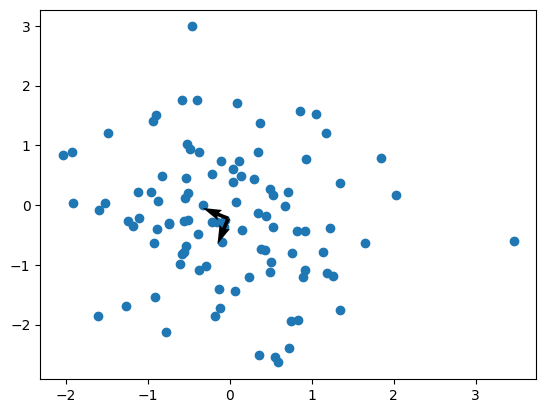

In [7]:
#7
norm_bi = [np.random.normal(0,1,100),np.random.normal(0,1,100)]
S_a = np.cov(norm_bi)
auto_va, auto_vec = np.linalg.eig(S_a)
(norm_bi)
plt.scatter(norm_bi[0],norm_bi[1])
plt.quiver(np.mean(norm_bi[0]),np.mean(norm_bi[1]),auto_va[0]*auto_vec[0][0],auto_va[0]*auto_vec[0][1])
plt.quiver(np.mean(norm_bi[0]),np.mean(norm_bi[1]),auto_va[1]*auto_vec[1][0],auto_va[1]*auto_vec[1][1])

PARTE PANDAS

In [8]:
#ex 1
iris = pd.read_csv("iris.csv")
iris.head(5)
iris.info,iris.isna


(<bound method DataFrame.info of      sepal.length  sepal.width  petal.length  petal.width    variety
 0             5.1          3.5           1.4          0.2     Setosa
 1             4.9          3.0           1.4          0.2     Setosa
 2             4.7          3.2           1.3          0.2     Setosa
 3             4.6          3.1           1.5          0.2     Setosa
 4             5.0          3.6           1.4          0.2     Setosa
 ..            ...          ...           ...          ...        ...
 145           6.7          3.0           5.2          2.3  Virginica
 146           6.3          2.5           5.0          1.9  Virginica
 147           6.5          3.0           5.2          2.0  Virginica
 148           6.2          3.4           5.4          2.3  Virginica
 149           5.9          3.0           5.1          1.8  Virginica
 
 [150 rows x 5 columns]>,
 <bound method DataFrame.isna of      sepal.length  sepal.width  petal.length  petal.width    variet

In [9]:
#2
iris.describe().loc[['mean',"std","min",'max']]

,sepal.length,sepal.width,petal.length,petal.width
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
max,7.900000,4.400000,6.900000,2.500000


In [10]:
#ex3
iris2 = pd.read_csv("iris.csv")
iris2_ = iris2[["petal.length","variety"]]
a = iris2_.groupby("variety")["petal.length"].agg(["mean","std"])
b = a.sort_values(by='mean', ascending=[False])
b

,mean,std
variety,,
Virginica,5.552,0.551895
Versicolor,4.260,0.469911
Setosa,1.462,0.173664


In [11]:
#4
iris2 = iris2[["petal.length","petal.width"]]
norm_df_iris = iris2.apply(lambda x:(x-x.mean())/x.std(),axis=0)
norm_df_iris

,petal.length,petal.width
0,-1.335752,-1.311052
1,-1.335752,-1.311052
2,-1.392399,-1.311052
3,-1.279104,-1.311052
4,-1.335752,-1.311052
...,...,...
145,0.816859,1.443994
146,0.703564,0.919223
147,0.816859,1.050416
148,0.930154,1.443994


In [12]:

#ex5
c = iris.query("variety=='Setosa'")
len(c)

50

In [13]:
#ex6
ver = iris.query("variety=='Versicolor'")
ver.to_csv
h = pd.read_csv("versicolor.csv")
len(h)

50

In [14]:
#ex7
ex7 = iris.query("variety=='Virginica' and `sepal.length`>6")
ex7.sort_values(by="petal.length")

,sepal.length,sepal.width,petal.length,petal.width,variety
126,6.2,2.8,4.8,1.8,Virginica
127,6.1,3.0,4.9,1.8,Virginica
123,6.3,2.7,4.9,1.8,Virginica
146,6.3,2.5,5.0,1.9,Virginica
141,6.9,3.1,5.1,2.3,Virginica
133,6.3,2.8,5.1,1.5,Virginica
110,6.5,3.2,5.1,2.0,Virginica
145,6.7,3.0,5.2,2.3,Virginica
147,6.5,3.0,5.2,2.0,Virginica
111,6.4,2.7,5.3,1.9,Virginica


MATPLOTLIB

Text(0, 0.5, 'Frequencia')

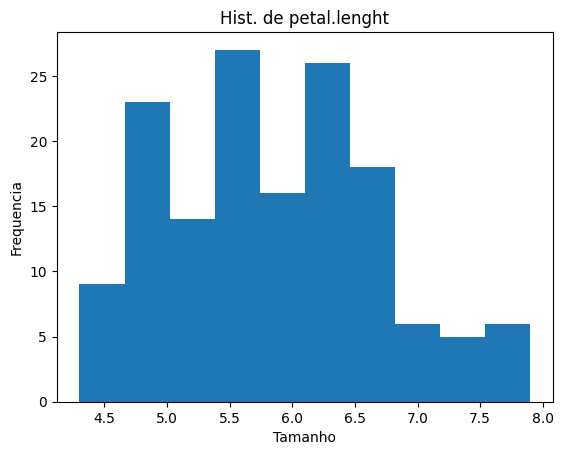

In [15]:
#1
iris3 = pd.read_csv('iris.csv')
plt.hist(iris3["sepal.length"])
plt.title("Hist. de petal.lenght")
plt.xlabel("Tamanho")
plt.ylabel("Frequencia")

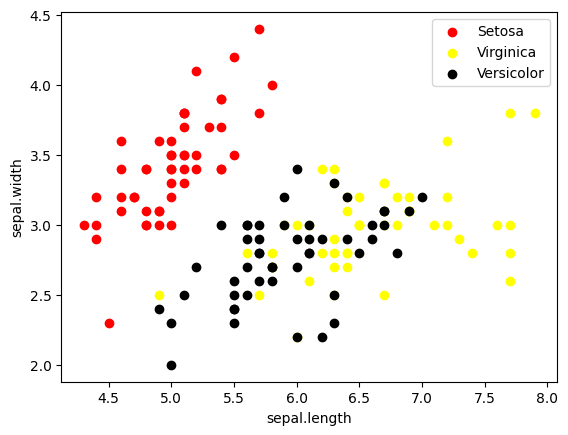

In [19]:
#2
dado1 = iris3.query("variety=='Setosa'")
dado2 = iris3.query("variety=='Virginica'")
dado3 = iris3.query("variety=='Versicolor'")

plt.scatter(dado1["sepal.length"],dado1["sepal.width"],color="red",label="Setosa")
plt.scatter(dado2["sepal.length"],dado2["sepal.width"],color="yellow",label="Virginica")
plt.scatter(dado3["sepal.length"],dado3["sepal.width"],color="black",label="Versicolor")
plt.xlabel("sepal.length")
plt.ylabel("sepal.width")
plt.legend()
plt.show()

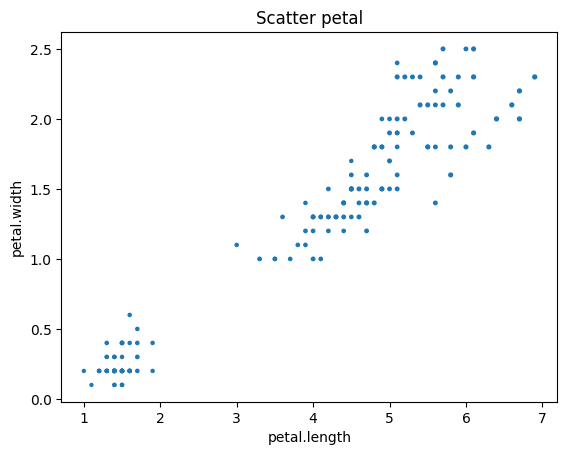

In [28]:
#3
plt.scatter(iris3["petal.length"],iris3["petal.width"],s=iris3["sepal.length"])
plt.xlabel("petal.length")
plt.ylabel("petal.width")
plt.title("Scatter petal")
plt.show()

Text(0.5, 1.0, 'Versicolor')

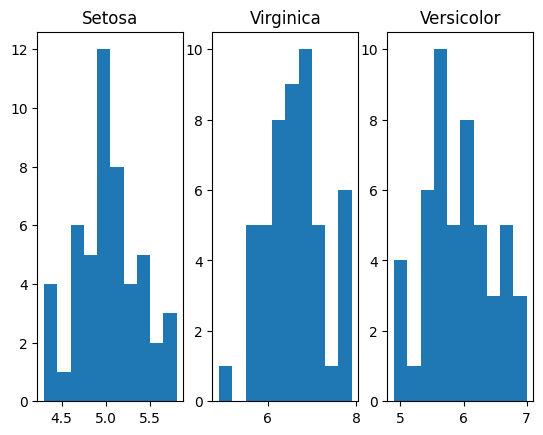

In [ ]:
#4
plt.subplot(1,3,1)
plt.hist(dado1["sepal.length"])
plt.title("Setosa")
plt.subplot(1,3,2)
plt.hist(dado2["sepal.length"])
plt.title("Virginica")
plt.subplot(1,3,3)
plt.hist(dado3["sepal.length"])
plt.title("Versicolor")

/var/folders/b0/d0xbbxmd447fjfd0jsx10zrm0000gn/T/ipykernel_22283/843612484.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([iris3["sepal.length"],iris3["sepal.width"],iris3["petal.length"],iris3["petal.width"]],


{'whiskers': [<matplotlib.lines.Line2D at 0x113791a90>,
 'caps': [<matplotlib.lines.Line2D at 0x113791d30>,
 'boxes': [<matplotlib.lines.Line2D at 0x113791940>,
 'medians': [<matplotlib.lines.Line2D at 0x113791fd0>,
 'fliers': [<matplotlib.lines.Line2D at 0x113792120>,
 'means': []}

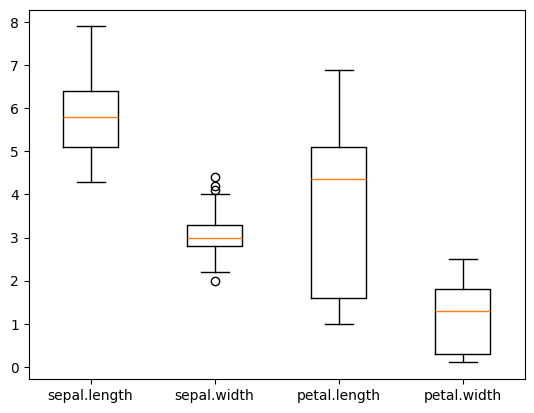

In [33]:
#5
plt.boxplot([iris3["sepal.length"],iris3["sepal.width"],iris3["petal.length"],iris3["petal.width"]],
            labels=["sepal.length","sepal.width","petal.length","petal.width"])

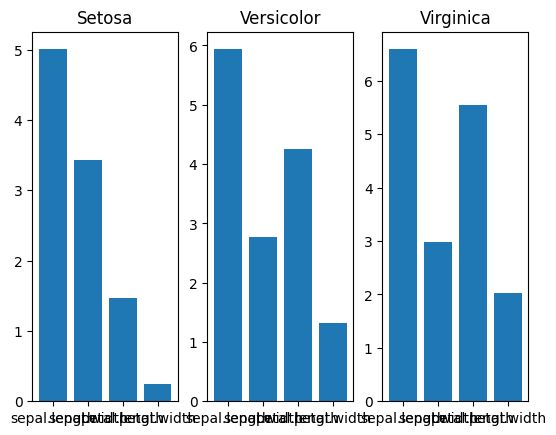

In [42]:
#6
j = iris3.groupby("variety").mean()
j
plt.subplot(1, 3, 1)
plt.bar(j.columns, j.loc["Setosa"])
plt.title("Setosa")
plt.subplot(1,3,2)
plt.bar(j.columns, j.loc["Versicolor"])
plt.title("Versicolor")
plt.subplot(1,3,3)
plt.bar(j.columns,j.loc["Virginica"])
plt.title("Virginica")
plt.show()

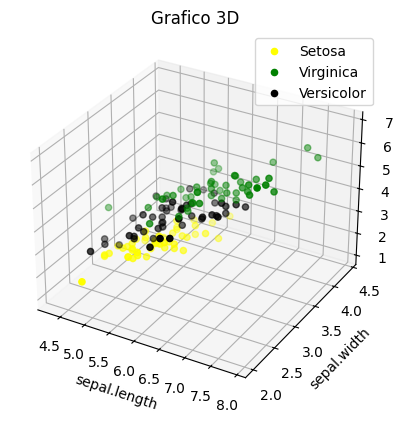

In [ ]:
#7
#